# HAR Pipeline v2 — IMU-first, VLM-assisted labeling

**Labels:** structured per segment — `Motion` (IMU: Idle/Walking/Running), `Context` and `Action` (VLM, open vocabulary) — collapsed into training classes by editable rules in Step 8. `Idle` covers both sitting and standing by design.

**Architecture change vs v1:**
1. **IMU decides motion** — Walking / Running / Idle are detected from the two wrist IMUs (free, instant, deterministic). The VLM was failing at this because ego-video + wrist sensors can't reliably see leg motion — but periodic gait impacts transmitted to *both* wrists can.
2. **VLM labels each segment once** with structured JSON `{context, action}`, and with the IMU motion state passed in so it never has to guess motion from pixels. Sitting vs standing is intentionally not classified — `Idle` covers both.
3. **Schema-constrained decoding** — Gemini must return valid JSON with exactly the `context` and `action` fields. Training classes are derived from these by rules, so the taxonomy can change without re-labeling.
4. **Parallel API calls** with real retries — no more `sleep(24)`.
5. **Fixed bugs:** windows no longer mix Left/Right wrist rows; validation plot now uses the same window parameters as extraction.

Typical result: 10–50× fewer API calls, consistent labels, minutes instead of hours.


In [3]:
#1 — installs
!pip -q install pymediainfo opencv-python google-genai

## Step 1 — Sync sensor data to video
`SYNC_MODE` controls how the video clock is aligned to the sensor clock. Camera metadata clocks (`encoded_date`) are often off by many seconds relative to the ESP32 clock — if you start both recordings together, `align_start` is the reliable choice (residual error = the gap between your two button presses). A warning fires automatically if metadata mode detects a suspicious clock disagreement.

In [4]:
#2 — video/sensor synchronization
import pandas as pd
import datetime, calendar, os
from pymediainfo import MediaInfo

VIDEO_FILE  = "video.mp4"
SENSOR_FILE = "sensors.csv"
SYNCED_FILE = "synced_data.csv"

# How to align the video clock to the sensor clock:
#   "align_start" - assume you started video + sensors together; ignore the video's
#                   absolute metadata time and pin video start to sensor start.
#                   RECOMMENDED when the two recordings have ~equal duration.
#   "metadata"    - trust the video's encoded_date (original behavior). Only safe if
#                   the camera clock and ESP32 clock are actually synchronized.
#   "manual"      - use MANUAL_OFFSET_MS: video_start = sensor_start + MANUAL_OFFSET_MS.
SYNC_MODE = "align_start"
MANUAL_OFFSET_MS = 0

def get_video_time_info(video_path):
    """Read end time + duration from video metadata -> (start_ms, end_ms) as Unix ms."""
    media_info = MediaInfo.parse(video_path)
    for track in media_info.tracks:
        if track.track_type == "General" and track.encoded_date:
            clean = track.encoded_date.replace("UTC", "").strip()
            dt = datetime.datetime.strptime(clean, "%Y-%m-%d %H:%M:%S")
            end_ms = calendar.timegm(dt.timetuple()) * 1000
            dur = int(track.duration) if track.duration else 0
            # ASSUMPTION: encoded_date == recording END. If your labels look shifted
            # by exactly the video duration, flip this to start_ms = end_ms.
            return end_ms - dur, end_ms
    return None, None

def synchronize(csv_path, video_path, out_path):
    v_start, v_end = get_video_time_info(video_path)
    if v_start is None:
        print("ERROR: no time info in video metadata."); return None
    v_dur = v_end - v_start

    df = pd.read_csv(csv_path)
    s_start, s_end = df['Timestamp_ms'].iloc[0], df['Timestamp_ms'].iloc[-1]
    s_dur = s_end - s_start

    if SYNC_MODE == "align_start":
        v_start = s_start
        v_end   = s_start + v_dur
    elif SYNC_MODE == "manual":
        v_start = s_start + MANUAL_OFFSET_MS
        v_end   = v_start + v_dur
    # "metadata": keep values from the file

    print(f"Sync mode: {SYNC_MODE}")
    print(f"Video  -> {v_start} .. {v_end}  ({v_dur/1000:.1f}s)")
    print(f"Sensor -> {s_start} .. {s_end}  ({s_dur/1000:.1f}s)")
    print(f"Trim: {max(0,(v_start-s_start)/1000):.2f}s head, {max(0,(s_end-v_end)/1000):.2f}s tail")

    # sanity check: near-equal durations but large clock offset => metadata clock is lying
    if SYNC_MODE == "metadata" and abs(v_dur - s_dur) < 3000 and abs(v_start - s_start) > 3000:
        print("WARNING: video and sensor durations match but their clocks disagree by "
              f"{abs(v_start - s_start)/1000:.1f}s. The video's encoded_date is probably "
              "wrong -> set SYNC_MODE = 'align_start'.")

    out = df[(df['Timestamp_ms'] >= v_start) & (df['Timestamp_ms'] <= v_end)].copy()
    if out.empty:
        print("ERROR: nothing left after trim — video and sensor times don't overlap."); return None
    out.to_csv(out_path, index=False)
    print(f"Saved {len(out)}/{len(df)} rows -> {out_path}")
    return v_start

if os.path.exists(VIDEO_FILE) and os.path.exists(SENSOR_FILE):
    VIDEO_START_MS = synchronize(SENSOR_FILE, VIDEO_FILE, SYNCED_FILE)
else:
    raise FileNotFoundError("video.mp4 or sensor_data.csv not found")

Sync mode: align_start
Video  -> 1784119847489 .. 1784120148118  (300.6s)
Sensor -> 1784119847489 .. 1784120033459  (186.0s)
Trim: 0.00s head, 0.00s tail
Saved 16909/16909 rows -> synced_data.csv


## Step 2 — Split devices, build time-based windows, extract IMU features
Your CSV interleaves `HARNode_Wrist_Left` and `HARNode_Wrist_Right` rows, so index-based windows (`iloc[start:start+100]`) mixed the two devices. Windows are now defined **by time** (2000 ms, 1000 ms step) and features are computed **per device**, then combined.

In [5]:
#3 — windowing + feature extraction
import numpy as np
import pandas as pd

WINDOW_MS = 2000
STEP_MS   = 1000

df = pd.read_csv("synced_data.csv")
t0, t1 = df['Timestamp_ms'].iloc[0], df['Timestamp_ms'].iloc[-1]

df['Device_Name'] = df['Device_Name'].astype(str).str.strip()
devices = sorted(df['Device_Name'].unique())
print("Devices found:", devices)

# explicit tag mapping — fail loudly instead of guessing
def device_tag(name):
    n = name.lower()
    if "left"  in n: return "L"
    if "right" in n: return "R"
    raise ValueError(f"Device name '{name}' contains neither 'Left' nor 'Right' — "
                     f"edit device_tag() to map your device names.")
TAGS = {d: device_tag(d) for d in devices}
if len(set(TAGS.values())) != len(TAGS):
    raise ValueError(f"Two devices mapped to the same tag: {TAGS}")
ACTIVE_TAGS = sorted(set(TAGS.values()))
if len(ACTIVE_TAGS) == 1:
    print(f"WARNING: only ONE wrist present ({devices}). "
          f"Classifier will run in single-wrist mode (less robust).")

streams = {d: df[df['Device_Name'] == d].reset_index(drop=True) for d in devices}
for d, s in streams.items():
    dt = np.diff(s['Timestamp_ms'].values)
    dt = dt[dt > 0]
    print(f"  {d}: {len(s)} rows, ~{1000/np.median(dt):.1f} Hz")

def dominant_freq(sig, ts_ms):
    """Dominant frequency (Hz) of a signal with (possibly uneven) timestamps."""
    if len(sig) < 8: return 0.0, 0.0
    t = (ts_ms - ts_ms[0]) / 1000.0
    fs = len(t) / max(t[-1], 1e-6)              # average sampling rate in window
    x = sig - sig.mean()
    spec = np.abs(np.fft.rfft(x * np.hanning(len(x))))
    freqs = np.fft.rfftfreq(len(x), d=1.0/fs)
    band = (freqs >= 0.8) & (freqs <= 5.0)      # human locomotion band
    if not band.any(): return 0.0, 0.0
    bi = np.where(band)[0]
    i = bi[np.argmax(spec[bi])]
    # parabolic interpolation around the peak bin: 2s windows have only 0.5 Hz
    # resolution, which quantizes cadence onto a coarse grid (1.0/1.5/2.0...)
    # and makes two wrists measuring the SAME cadence land on different bins.
    # Sub-bin interpolation recovers ~0.1 Hz resolution from the same window.
    if 0 < i < len(spec) - 1 and spec[i] > 0:
        a, b, c = spec[i-1], spec[i], spec[i+1]
        denom = a - 2*b + c
        delta = 0.5 * (a - c) / denom if abs(denom) > 1e-12 else 0.0
        delta = float(np.clip(delta, -0.5, 0.5))
    else:
        delta = 0.0
    bin_hz = freqs[1] - freqs[0]
    f_peak = float(freqs[i] + delta * bin_hz)
    total = spec[1:].sum() + 1e-9
    return f_peak, float(spec[i] / total)   # freq, relative peak power

def window_features(s, w_start, w_end):
    m = (s['Timestamp_ms'] >= w_start) & (s['Timestamp_ms'] < w_end)
    w = s[m]
    if len(w) < 8: return None
    acc  = np.sqrt(w['AccX']**2 + w['AccY']**2 + w['AccZ']**2).values
    gyro = np.sqrt(w['GyroX']**2 + w['GyroY']**2 + w['GyroZ']**2).values
    f, p = dominant_freq(acc, w['Timestamp_ms'].values)
    return dict(acc_std=float(acc.std()), gyro_mean=float(gyro.mean()),
                dom_freq=f, peak_power=p)

rows = []
w_start, wid = t0, 0
while w_start + WINDOW_MS <= t1:
    w_end = w_start + WINDOW_MS
    feats = {d: window_features(streams[d], w_start, w_end) for d in devices}
    if all(f is not None for f in feats.values()):
        r = {"Window_ID": wid, "Start_ms": int(w_start), "End_ms": int(w_end)}
        for d, f in feats.items():
            for k, v in f.items(): r[f"{TAGS[d]}_{k}"] = v
        rows.append(r); wid += 1
    w_start += STEP_MS

W = pd.DataFrame(rows)
print(f"\n{len(W)} windows of {WINDOW_MS} ms (step {STEP_MS} ms)")
W.head(3)

Devices found: ['HARNode_Wrist_Left', 'HARNode_Wrist_Right']
  HARNode_Wrist_Left: 8455 rows, ~35.7 Hz
  HARNode_Wrist_Right: 8454 rows, ~30.3 Hz

184 windows of 2000 ms (step 1000 ms)


,Window_ID,Start_ms,End_ms,L_acc_std,L_gyro_mean,L_dom_freq,L_peak_power,R_acc_std,R_gyro_mean,R_dom_freq,R_peak_power
0,0,1784119847489,1784119849489,0.158041,123.359678,1.598405,0.122010,0.279236,75.775972,1.627973,0.136340
1,1,1784119848489,1784119850489,0.288198,139.992755,1.871332,0.172278,0.248530,95.892095,1.670143,0.147673
2,2,1784119849489,1784119851489,0.313173,174.548991,1.859195,0.188279,0.311489,134.223526,1.712393,0.137177


## Step 3 — IMU motion classifier: Idle / Walking / Running
Logic: locomotion produces **periodic impacts on both wrists at (nearly) the same frequency**. A single busy hand (stirring, writing) is periodic on *one* wrist only → stays Idle. Thresholds are exposed below; the scatter plot shows your data so you can tune them in 30 seconds.

Motion
Walking    123
Idle        61
Name: count, dtype: int64

After smoothing:
Motion
Walking    135
Idle        49
Name: count, dtype: int64


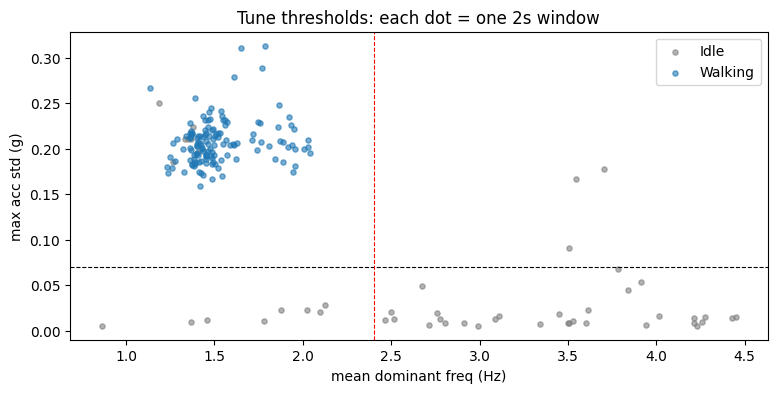

In [6]:
#4 — IMU classification + calibration plot
import matplotlib.pyplot as plt

# ---- thresholds (tune with the plot below) ----
ACC_STD_MIN   = 0.07   # g  — minimum motion energy for locomotion
                       #      (0.07 fits relaxed-arm walking ~0.10-0.18 g;
                       #       raise it if desk work triggers false Walking)
FREQ_MATCH_HZ = 0.65   # Hz — cadence agreement tolerance. Must exceed the FFT
                       #      bin spacing (0.5 Hz at 2s windows), or two wrists
                       #      measuring the same cadence can 'disagree' by construction
RUN_FREQ_HZ   = 2.4    # Hz — cadence above this = Running
RUN_ACC_STD   = 0.60   # g  — or impact energy above this = Running
# -----------------------------------------------

def classify_row(r):
    stds  = [r[f"{t}_acc_std"]  for t in ACTIVE_TAGS]
    freqs = [r[f"{t}_dom_freq"] for t in ACTIVE_TAGS]
    energetic = all(s > ACC_STD_MIN for s in stds)
    in_band   = all(f > 0.9 for f in freqs)

    def freqs_agree(f1, f2, tol=FREQ_MATCH_HZ):
        # harmonic-aware: arm swing runs at HALF the step rate (one swing per stride),
        # so one wrist can lock onto 1 Hz while the other locks onto 2 Hz during the
        # same walk. Treat f, 2f pairs as agreement, not disagreement.
        if abs(f1 - f2) < tol: return True
        # doubled comparisons get 1.5x tolerance: FFT bin error doubles with the frequency
        return abs(2 * f1 - f2) < 1.5 * tol or abs(f1 - 2 * f2) < 1.5 * tol

    if len(ACTIVE_TAGS) == 2:
        cadence_ok = in_band and freqs_agree(freqs[0], freqs[1])
    else:  # single-wrist mode: rhythm strength instead of cross-wrist agreement
        cadence_ok = in_band and r[f"{ACTIVE_TAGS[0]}_peak_power"] > 0.10
    if energetic and cadence_ok:
        # if the wrists sit on different harmonics, the HIGHER one is the step
        # frequency — use it for the walk/run decision, not the misleading mean
        if len(freqs) == 2 and abs(freqs[0] - freqs[1]) >= FREQ_MATCH_HZ:
            f = max(freqs)
        else:
            f = sum(freqs) / len(freqs)
        e = max(stds)
        return "Running" if (f >= RUN_FREQ_HZ or e >= RUN_ACC_STD) else "Walking"
    return "Idle"


W["Motion"] = W.apply(classify_row, axis=1)
print(W["Motion"].value_counts())

# temporal smoothing: kill single-window flickers (mode over 3 windows)
def smooth(labels, k=3):
    out = labels.copy()
    for i in range(1, len(labels)-1):
        seg = labels[i-1:i+2]
        out[i] = max(set(seg), key=seg.count)
    return out
W["Motion"] = smooth(W["Motion"].tolist())
print("\nAfter smoothing:"); print(W["Motion"].value_counts())

# calibration plot
fig, ax = plt.subplots(figsize=(9,4))
colors = {"Idle":"tab:gray","Walking":"tab:blue","Running":"tab:red"}
freq_cols = [f"{t}_dom_freq" for t in ACTIVE_TAGS]
std_cols  = [f"{t}_acc_std"  for t in ACTIVE_TAGS]
for lab, g in W.groupby("Motion"):
    ax.scatter(g[freq_cols].mean(axis=1),
               g[std_cols].max(axis=1),
               s=14, alpha=.6, label=lab, c=colors.get(lab,"k"))
ax.axhline(ACC_STD_MIN, ls="--", c="k", lw=.8); ax.axvline(RUN_FREQ_HZ, ls="--", c="r", lw=.8)
ax.set_xlabel("mean dominant freq (Hz)"); ax.set_ylabel("max acc std (g)")
ax.legend(); ax.set_title("Tune thresholds: each dot = one 2s window"); plt.show()

### Step 3b — Diagnostic: why did windows get these labels?
If everything comes out `Idle` (or everything `Walking`), look here. Top plot: motion energy per window for both wrists, with the `ACC_STD_MIN` line. Bottom: dominant frequency per wrist, with the locomotion band. Walking windows should show energy above the dashed line **and** both wrists tracking the same frequency around 1.5–2.5 Hz.

- Energy above the line but still labeled Idle -> the wrists disagree on cadence: raise `FREQ_MATCH_HZ` (e.g. 0.8) or lower the `> 0.9` Hz floor in `classify_row`.
- Energy below the line during walking -> lower `ACC_STD_MIN` (hands in pockets / holding a phone reduce arm swing a lot).
- Flat near-zero energy everywhere -> the recording really is stationary, or the wrong sensor file is loaded.

After changing thresholds, re-run the Step 3 cell and this one.

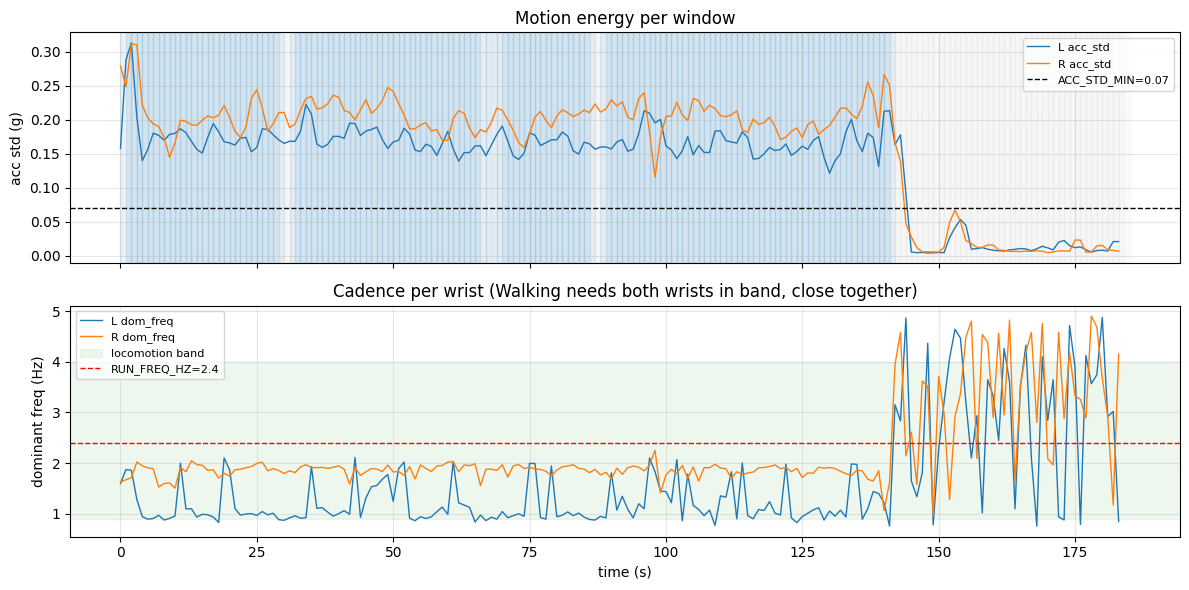

       L_acc_std  R_acc_std  L_dom_freq  R_dom_freq
count    184.000    184.000     184.000     184.000
mean       0.136      0.164       1.585       2.191
std        0.068      0.083       1.015       0.839
min        0.004      0.004       0.754       0.947
25%        0.142      0.166       0.942       1.821
50%        0.162      0.197       1.084       1.899
75%        0.176      0.214       1.900       1.971
max        0.313      0.311       4.874       4.899


In [7]:
#4b — feature timeline diagnostic
import matplotlib.pyplot as plt

t_rel = (W.Start_ms - W.Start_ms.iloc[0]) / 1000.0
fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

freq_cols = [f"{t}_dom_freq" for t in ACTIVE_TAGS]
std_cols  = [f"{t}_acc_std"  for t in ACTIVE_TAGS]
for t in ACTIVE_TAGS:
    a1.plot(t_rel, W[f"{t}_acc_std"], label=f"{t} acc_std", lw=1)
a1.axhline(ACC_STD_MIN, ls="--", c="k", lw=1, label=f"ACC_STD_MIN={ACC_STD_MIN}")
a1.set_ylabel("acc std (g)"); a1.legend(fontsize=8); a1.grid(alpha=.3)
a1.set_title("Motion energy per window")

for t in ACTIVE_TAGS:
    a2.plot(t_rel, W[f"{t}_dom_freq"], label=f"{t} dom_freq", lw=1)
a2.axhspan(0.9, 4.0, color="tab:green", alpha=.08, label="locomotion band")
a2.axhline(RUN_FREQ_HZ, ls="--", c="r", lw=1, label=f"RUN_FREQ_HZ={RUN_FREQ_HZ}")
a2.set_ylabel("dominant freq (Hz)"); a2.set_xlabel("time (s)")
a2.legend(fontsize=8); a2.grid(alpha=.3)
a2.set_title("Cadence per wrist (Walking needs both wrists in band, close together)")

# color strip of resulting labels
colors = {"Idle":"lightgray","Walking":"tab:blue","Running":"tab:red"}
for _, r in W.iterrows():
    a1.axvspan((r.Start_ms - W.Start_ms.iloc[0])/1000,
               (r.End_ms   - W.Start_ms.iloc[0])/1000,
               color=colors.get(r.Motion, "yellow"), alpha=.10)
plt.tight_layout(); plt.show()

print(W[std_cols + freq_cols].describe().round(3))

## Step 4 — Merge windows into segments
Contiguous windows with the same motion state become one **segment**. Micro-fragments shorter than `MIN_SEGMENT_S` (default 5 s) are absorbed into their neighbors first — a 2-second arm pause while opening a door should not split a walk into three segments. Then the VLM is called once per **segment**: one long walk = dozens of windows but a single call.

In [8]:
#5 — segment merging with minimum duration
# Segments shorter than MIN_SEGMENT_S are absorbed into their neighbors:
#   Walking | 2s Idle | Walking  -> one Walking segment (bridge)
#   Walking | 2s Running | Idle  -> merged into the longer neighbor
# This removes micro-fragments (door pauses, glances, single hard footfalls)
# so labels describe the ongoing activity, not every 2-second interruption.
MIN_SEGMENT_S = 5.0

def runs(labels):
    out, s = [], 0
    for i in range(1, len(labels) + 1):
        if i == len(labels) or labels[i] != labels[s]:
            out.append([s, i - 1, labels[s]]); s = i
    return out

def enforce_min_duration(W, min_s):
    labels = W["Motion"].tolist()
    dur = lambda r: (W.End_ms.iloc[r[1]] - W.Start_ms.iloc[r[0]]) / 1000.0
    while True:
        rr = runs(labels)
        if len(rr) <= 1: break
        short = [r for r in rr if dur(r) < min_s]
        if not short: break
        r = min(short, key=dur)                      # fix the shortest first
        i = rr.index(r)
        prev = rr[i - 1] if i > 0 else None
        nxt  = rr[i + 1] if i < len(rr) - 1 else None
        if prev and nxt and prev[2] == nxt[2]:
            new_lab = prev[2]                        # bridge
        elif prev and (nxt is None or dur(prev) >= dur(nxt)):
            new_lab = prev[2]                        # absorb into longer neighbor
        else:
            new_lab = nxt[2]
        for k in range(r[0], r[1] + 1): labels[k] = new_lab
    return labels

n_before = (W["Motion"] != W["Motion"].shift()).sum()
W["Motion"] = enforce_min_duration(W, MIN_SEGMENT_S)
n_after = (W["Motion"] != W["Motion"].shift()).sum()
print(f"Segments: {n_before} -> {n_after} after enforcing >= {MIN_SEGMENT_S}s")

segments = []
cur = None
for _, r in W.iterrows():
    if cur is None or r.Motion != cur["Motion"]:
        if cur is not None: segments.append(cur)
        cur = dict(Motion=r.Motion, Start_ms=r.Start_ms, End_ms=r.End_ms,
                   first_w=int(r.Window_ID), last_w=int(r.Window_ID))
    else:
        cur["End_ms"] = r.End_ms; cur["last_w"] = int(r.Window_ID)
if cur is not None: segments.append(cur)

seg_df = pd.DataFrame(segments)
seg_df["dur_s"] = (seg_df.End_ms - seg_df.Start_ms) / 1000
print(f"{len(seg_df)} segments total -> {len(seg_df)} VLM calls instead of {len(W)}")
seg_df

Segments: 10 -> 2 after enforcing >= 5.0s
2 segments total -> 2 VLM calls instead of 184


,Motion,Start_ms,End_ms,first_w,last_w,dur_s
0,Walking,1784119847489,1784119989489,0,140,142.0
1,Idle,1784119988489,1784120032489,141,183,44.0


## Step 5 — VLM chunks + frame extraction
Motion segments stay long (good for classifier labels), but the VLM labels **chunks** of at most `MAX_VLM_CHUNK_S` seconds, so context that changes mid-segment (hallway -> stairs -> street inside one walk) is captured instead of averaged away. Up to 3 frames per chunk; seeks in time order.

In [9]:
#6 — split segments into VLM chunks, extract frames per chunk
import cv2, os
import numpy as np

# Motion segments can be minutes long, but CONTEXT changes faster (hallway ->
# stairs -> street inside one walk). Cap the unit the VLM sees:
MAX_VLM_CHUNK_S = 25.0

chunks = []
for si, seg in seg_df.iterrows():
    dur_ms = seg.End_ms - seg.Start_ms
    n = max(1, int(np.ceil(dur_ms / (MAX_VLM_CHUNK_S * 1000))))
    edges = np.linspace(seg.Start_ms, seg.End_ms, n + 1)
    for k in range(n):
        chunks.append(dict(seg_idx=si, Motion=seg.Motion,
                           Start_ms=int(edges[k]), End_ms=int(edges[k+1])))
chunk_df = pd.DataFrame(chunks)
print(f"{len(seg_df)} segments -> {len(chunk_df)} VLM chunks (max {MAX_VLM_CHUNK_S}s each)")

FRAMES_FOLDER = "VLM_Frames_Chunks"
os.makedirs(FRAMES_FOLDER, exist_ok=True)

jobs = []
for ci, ch in chunk_df.iterrows():
    dur = ch.End_ms - ch.Start_ms
    fracs = [0.5] if dur < 3000 else [0.2, 0.5, 0.8]
    for fi, frac in enumerate(fracs):
        t_ms = (ch.Start_ms + frac * dur) - VIDEO_START_MS
        jobs.append((t_ms, ci, fi))
jobs.sort()

cap = cv2.VideoCapture("video.mp4")
chunk_frames = {ci: [] for ci in chunk_df.index}
for t_ms, ci, fi in jobs:
    cap.set(cv2.CAP_PROP_POS_MSEC, max(0, t_ms))
    ok, frame = cap.read()
    if ok:
        name = f"chunk_{ci:03d}_f{fi}.jpg"
        cv2.imwrite(os.path.join(FRAMES_FOLDER, name), frame,
                    [cv2.IMWRITE_JPEG_QUALITY, 85])
        chunk_frames[ci].append(name)
cap.release()
print(f"Extracted {sum(len(v) for v in chunk_frames.values())} frames "
      f"for {len(chunk_df)} chunks")

2 segments -> 8 VLM chunks (max 25.0s each)
Extracted 24 frames for 8 chunks


## Step 6 — VLM: structured labels `{context, action}` per segment

Instead of one word, every segment gets **two fields** in one API call, enforced as JSON:

- **`context`** — where / what scenario the wearer is in: `kitchen`, `office`, `train`, `street`, `supermarket`, ... Scene recognition is what VLMs are most reliable at.
- **`action`** — short open-vocabulary verb phrase for what the wearer is doing: `chopping vegetables`, `typing on laptop`, `walking down stairs`, `scrolling phone`.

The IMU motion state (Idle / Walking / Running) is passed in as context so the VLM never guesses motion from pixels. Posture (sitting vs standing) is deliberately **not** a field — `Idle` covers both.

Your final training classes (e.g. *Cooking*, *Using train*) are NOT assigned here — they're derived in Step 8 from these fields by editable rules. Change your taxonomy anytime without re-calling the API.

In [10]:
#7 — parallel VLM labeling: structured {context, action} per segment
import time, os, json
from concurrent.futures import ThreadPoolExecutor, as_completed
from google import genai
from google.genai import types
from google.colab import userdata
from PIL import Image

client = genai.Client(api_key=userdata.get('GEMINI_API_KEY'))
MODEL = "gemini-2.5-flash"

MOTION_HINT = {
    "Idle":    "Motion sensors show the wearer is STATIONARY (not walking or running).",
    "Walking": "Motion sensors show the wearer is WALKING.",
    "Running": "Motion sensors show the wearer is RUNNING.",
}

def build_prompt(motion):
    return f"""These photos span one activity segment from a FIRST-PERSON wearable camera (smart glasses).

{MOTION_HINT[motion]}

Describe what the CAMERA WEARER is doing. Ignore all other people visible in the
photos — never describe their actions, only the wearer's.

Return JSON with exactly these fields:
- "context": the wearer's location/scenario, 1-2 lowercase words
  (examples: kitchen, office, train, bus, street, supermarket, living room, stairs, car)
- "action": what the wearer is doing, a short lowercase verb phrase of 1-4 words
  (examples: chopping vegetables, typing on laptop, scrolling phone, washing dishes,
   carrying bag, looking around)"""

GEN_CONFIG = types.GenerateContentConfig(
    temperature=0,
    thinking_config=types.ThinkingConfig(thinking_budget=0),
    response_mime_type="application/json",
    response_schema={
        "type": "OBJECT",
        "properties": {
            "context": {"type": "STRING"},
            "action":  {"type": "STRING"},
        },
        "required": ["context", "action"],
    },
)

def label_segment(si, motion, filenames):
    imgs = [Image.open(os.path.join(FRAMES_FOLDER, f)) for f in filenames]
    delay = 2.0
    for attempt in range(5):
        try:
            resp = client.models.generate_content(
                model=MODEL, contents=[build_prompt(motion), *imgs], config=GEN_CONFIG)
            text = (resp.text or "").strip()
            if text:
                d = json.loads(text)
                return si, d.get("context", "unknown").strip().lower(),                            d.get("action",  "unknown").strip().lower()
            time.sleep(delay); delay *= 2   # empty answer -> retry
        except json.JSONDecodeError:
            time.sleep(delay); delay *= 2   # malformed JSON -> retry
        except Exception as e:
            msg = str(e)
            if "429" in msg or "RESOURCE_EXHAUSTED" in msg or "503" in msg:
                time.sleep(delay); delay *= 2
            else:
                print(f"seg {si}: {e}")
                return si, "unknown", "unknown"
    return si, "unknown", "unknown"

results = {}
todo = [(ci, ch.Motion, chunk_frames[ci]) for ci, ch in chunk_df.iterrows() if chunk_frames[ci]]
print(f"Labeling {len(todo)} chunks (v1 made {len(W)} calls — one per window)\n")
with ThreadPoolExecutor(max_workers=8) as pool:
    futs = [pool.submit(label_segment, ci, mo, fs) for ci, mo, fs in todo]
    for fut in as_completed(futs):
        ci, ctx, act = fut.result()
        results[ci] = (ctx, act)
        print(f"chunk {ci:3d} ({chunk_df.loc[ci, 'Motion']:>7}) -> context: {ctx!r:20s} action: {act!r}")

chunk_df["Context"] = chunk_df.index.map(lambda i: results.get(i, ("unknown","unknown"))[0])
chunk_df["Action"]  = chunk_df.index.map(lambda i: results.get(i, ("unknown","unknown"))[1])
chunk_df[["Motion","Start_ms","End_ms","Context","Action"]]

Labeling 8 chunks (v1 made 184 calls — one per window)

chunk   4 (Walking) -> context: 'park'               action: 'walking'
chunk   1 (Walking) -> context: 'park path'          action: 'walking'
chunk   0 (Walking) -> context: 'street'             action: 'walking'
chunk   6 (   Idle) -> context: 'park'               action: 'using phone'
chunk   3 (Walking) -> context: 'park path'          action: 'walking with phone'
chunk   5 (Walking) -> context: 'park'               action: 'walking'
chunk   2 (Walking) -> context: 'park path'          action: 'walking'
chunk   7 (   Idle) -> context: 'park'               action: 'using phone'


,Motion,Start_ms,End_ms,Context,Action
0,Walking,1784119847489,1784119871155,street,walking
1,Walking,1784119871155,1784119894822,park path,walking
2,Walking,1784119894822,1784119918489,park path,walking
3,Walking,1784119918489,1784119942155,park path,walking with phone
4,Walking,1784119942155,1784119965822,park,walking
5,Walking,1784119965822,1784119989489,park,walking
6,Idle,1784119988489,1784120010489,park,using phone
7,Idle,1784120010489,1784120032489,park,using phone


## Step 7 — Per-window structured labels
Segment fields are propagated to every window. The output CSV keeps all three raw fields (`Motion`, `Context`, `Action`) — this file is your permanent ground truth. Never overwrite it when the taxonomy changes.

In [11]:
#8 — assemble per-window structured labels
final = W[["Window_ID","Start_ms","End_ms","Motion"]].copy()
final["Context"] = "unknown"
final["Action"]  = "unknown"

# a window belongs to the chunk containing its midpoint
mid = (final.Start_ms + final.End_ms) / 2
for ci, ch in chunk_df.iterrows():
    m = (mid >= ch.Start_ms) & (mid < ch.End_ms)
    final.loc[m, "Context"] = ch.Context
    final.loc[m, "Action"]  = ch.Action

# failed chunks inherit nearest labeled chunk with the same Motion
known = chunk_df[chunk_df.Context != "unknown"]
for ci, ch in chunk_df[chunk_df.Context == "unknown"].iterrows():
    cand = known[known.Motion == ch.Motion]
    if cand.empty: cand = known
    if cand.empty: break
    nearest = cand.iloc[(cand.Start_ms - ch.Start_ms).abs().argmin()]
    m = (mid >= ch.Start_ms) & (mid < ch.End_ms)
    final.loc[m, ["Context","Action"]] = [nearest.Context, nearest.Action]

final.to_csv("windows_structured.csv", index=False)
print(final.groupby(["Motion","Context","Action"]).size())

Motion   Context    Action            
Idle     park       using phone           43
Walking  park       using phone            1
                    walking               46
         park path  walking               47
                    walking with phone    24
         street     walking               23
dtype: int64


## Step 8 — Taxonomy: derive training classes from the fields
This is the ONLY place your class list lives. Rules are checked top-to-bottom, first match wins; anything unmatched becomes `Other`. When you or your supervisors change the taxonomy, edit the rules and re-run this one cell — no API calls, no touching the raw data.

Keep an eye on the `Other` bucket: it shows what your taxonomy doesn't cover yet.

In [12]:
#9 — editable taxonomy rules -> final training labels
# Each rule: (ClassName, function(row) -> bool). First match wins.
TAXONOMY = [
    ("Running",     lambda r: r.Motion == "Running"),
    ("Walking",     lambda r: r.Motion == "Walking"),
    ("Cooking",     lambda r: "kitchen" in r.Context or
                              any(w in r.Action for w in ["cook","chop","stir","fry","wash dish"])),
    ("Using train", lambda r: any(w in r.Context for w in ["train","metro","subway","tram"])),
    ("Desk work",   lambda r: any(w in r.Action for w in ["typ","comput","writ","laptop"])),
    ("Phone use",   lambda r: "phone" in r.Action),
    ("Eating",      lambda r: any(w in r.Action for w in ["eat","drink"])),
]

def apply_taxonomy(r):
    for name, rule in TAXONOMY:
        try:
            if rule(r): return name
        except Exception:
            pass
    return "Other"

final["Label"] = final.apply(apply_taxonomy, axis=1)
final.to_csv("windows_labeled_final.csv", index=False)

print(final.Label.value_counts()); print()
others = final[final.Label == "Other"][["Motion","Context","Action"]].drop_duplicates()
if len(others):
    print("Unmatched (Context, Action) pairs — extend TAXONOMY if these matter:")
    print(others.to_string(index=False))

Label
Walking      141
Phone use     43
Name: count, dtype: int64



## Step 8 — Validation plot (fixed)
The v1 validation cell used `window_size=200, step=100` while extraction used `100/50`, so it plotted the wrong data. This version derives everything from the same `Start_ms`/`End_ms` the labels were built from, and shows both wrists.

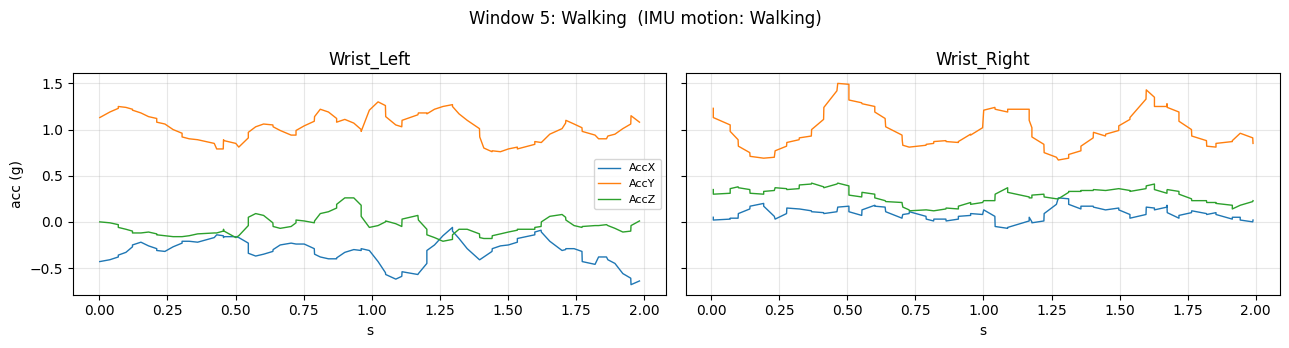

In [13]:
#9 — visual check of any window
import matplotlib.pyplot as plt

def check_window(window_id):
    r = final[final.Window_ID == window_id].iloc[0]
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), sharey=True)
    for ax, d in zip(axes, devices):
        s = streams[d]
        m = (s.Timestamp_ms >= r.Start_ms) & (s.Timestamp_ms < r.End_ms)
        w = s[m]
        t = (w.Timestamp_ms - r.Start_ms) / 1000
        for axis in ["AccX","AccY","AccZ"]:
            ax.plot(t, w[axis], label=axis, lw=1)
        ax.set_title(d.replace("HARNode_","")); ax.set_xlabel("s"); ax.grid(alpha=.3)
    axes[0].set_ylabel("acc (g)"); axes[0].legend(fontsize=8)
    fig.suptitle(f"Window {window_id}: {r.Label}  (IMU motion: {r.Motion})")
    plt.tight_layout(); plt.show()

check_window(5)